# Credit Risk Portfolio Model

This project builds and compares machine-learning models to estimate the probability that a Lending Club loan will default. The analysis then uses the selected model to estimate expected credit loss, run stress scenarios, and explain the main drivers of predicted default risk.

## 1. Data Exploration

I begin by loading the 100,000-loan sample and reviewing its structure, summary statistics, columns, and loan-status distribution.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('lending_club_100k.csv', low_memory=False)

In [3]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,...,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,9.321600e+04,0.0,93216.000000,93216.000000,93216.000000,93216.000000,93216.000000,9.321600e+04,93214.000000,93216.000000,...,725.0,725.000000,725.0,725.000000,575.00000,725.000000,725.000000,2799.000000,2799.000000,2799.000000
mean,6.552332e+07,NaN,15032.294349,15032.294349,15023.012948,12.214209,433.907835,7.839631e+04,19.287899,0.349972,...,3.0,127.613545,3.0,14.059310,379.23840,10208.093214,185.859421,4960.046149,47.158685,13.666309
std,2.373149e+06,NaN,8641.380403,8641.380403,8636.135680,4.139002,246.190268,9.095127e+04,9.679736,0.921600,...,0.0,103.499544,0.0,9.703224,307.59549,6313.721490,178.250692,3503.241922,5.624070,7.450152
min,5.670500e+04,NaN,1000.000000,1000.000000,900.000000,5.320000,14.770000,0.000000e+00,0.000000,0.000000,...,3.0,0.640000,3.0,0.000000,1.92000,55.730000,0.020000,186.000000,20.000000,0.000000
25%,6.407855e+07,NaN,8000.000000,8000.000000,8000.000000,9.170000,255.452500,4.784000e+04,12.610000,0.000000,...,3.0,48.140000,3.0,7.000000,143.77500,5078.300000,46.400000,2121.500000,45.000000,8.000000
50%,6.571292e+07,NaN,13800.000000,13800.000000,13750.000000,11.990000,377.395000,6.500000e+04,18.740000,0.000000,...,3.0,101.420000,3.0,15.000000,301.53000,9168.130000,136.240000,4290.000000,45.000000,14.000000
75%,6.658345e+07,NaN,20000.000000,20000.000000,20000.000000,14.480000,571.340000,9.400000e+04,25.560000,0.000000,...,3.0,174.020000,3.0,23.000000,520.12500,14667.450000,272.230000,6939.500000,50.000000,18.000000
max,6.861706e+07,NaN,35000.000000,35000.000000,35000.000000,28.990000,1354.660000,9.000000e+06,999.000000,30.000000,...,3.0,638.130000,3.0,30.000000,1914.39000,29401.040000,926.410000,23105.580000,97.660000,65.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93216 entries, 0 to 93215
Columns: 151 entries, id to settlement_term
dtypes: float64(114), int64(1), object(36)
memory usage: 107.4+ MB


In [6]:
for c in df.columns:
  print(c)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
fico_range_low
fico_range_high
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
last_fico_range_high
last_fico_range_low
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
to

### Target Variable

`loan_status` contains several loan states, including loans that are still current. For a completed-outcome classification problem, I focus on **Fully Paid** and **Charged Off** loans. I map Fully Paid to 0 and Charged Off to 1 so that class 1 represents default/charge-off.


In [7]:
# Investigate our target variable's values AKA ['loan_status']

df['loan_status'].value_counts()

,count
loan_status,
Fully Paid,65429
Charged Off,16506
Current,10623
Late (31-120 days),406
In Grace Period,185
Late (16-30 days),66
Default,1


In [8]:
# Only include loans that were fully paid off or defaulted

df = df[
    df["loan_status"].isin(["Fully Paid", "Charged Off"])
].copy()

In [9]:
# Map target variable to 0 and 1 for modeling later

df["default"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

### Feature Selection

I select borrower and loan characteristics that are available for modeling and separate them from the binary default target. This keeps the model focused on a manageable set of economically interpretable credit-risk features.


In [10]:
# Feature selection

features = [  "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "purpose",
    "dti",
    "fico_range_low",
    "fico_range_high",
    "revol_util"]

X = df[features]
y = df['default']

### Train/Test Split

The data is split before fitting preprocessing steps or models. This keeps the test set separate from model training and gives a cleaner estimate of out-of-sample performance.


In [11]:
from sklearn.model_selection import train_test_split

In [12]:
#Split the data to prevent leakage

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=19,
                                                    stratify=y)

print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

X_train: (65548, 15)
X_test: (16387, 15)


### Preprocessing Pipeline

Numerical and categorical variables require different preprocessing. Numerical features are imputed with their median and, for Logistic Regression, standardized. Categorical features are imputed with their most frequent value and one-hot encoded. Putting these steps in a pipeline helps prevent inconsistent preprocessing between training and testing.


In [13]:
# Seperate data types in order to insert them easier into the pipeline

numeric_features = X.select_dtypes(exclude='object')
categorical_features = X.select_dtypes(include='object')

print(f'Numeric Shape: {numeric_features.shape}')
print(f'Categorical Shape: {categorical_features.shape}')

Numeric Shape: (81935, 8)
Categorical Shape: (81935, 7)


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [15]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [16]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first',
                             handle_unknown='ignore'))
])

In [17]:
from sklearn.compose import ColumnTransformer

In [18]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features.columns),
    ('cat', categorical_pipeline, categorical_features.columns)
])

## 2. Logistic Regression — Base Model

Logistic Regression provides a useful baseline for the classification problem. The preprocessing and classifier are combined in a pipeline so that missing-value treatment, scaling, categorical encoding, and prediction are handled consistently.


In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=19
    ))
])

In [21]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
       'fico_range_low', 'fico_range_high', 'revol_util'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index(['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       'verification_status', 'purpose'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=19))])

In [22]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [23]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
     precision_score,
    recall_score,
    f1_score
)

### Model Evaluation

The evaluation function keeps model comparisons consistent. It reports ROC-AUC using predicted probabilities and calculates classification metrics at a chosen decision threshold. This is useful because threshold-dependent metrics such as recall and F1 can change substantially even when the underlying ROC-AUC does not.


In [24]:
def evaluate_model(model_name, model, X_test, y_test, thresh = 0.5):

  y_pred = model.predict(X_test)
  y_prob = model.predict_proba(X_test)[:, 1]
  y_thresh_pred = (y_prob >= thresh).astype(int)

  results = pd.DataFrame({
      "Model": [model_name],
      "Precision Score": [round(precision_score(y_test, y_thresh_pred), 2)],
      "Recall Score": [round(recall_score(y_test, y_thresh_pred), 2)],
      "F1 Score": [round(f1_score(y_test, y_thresh_pred), 2)]
  })

  return results

In [25]:
log_results = evaluate_model("Log", model, X_test, y_test)

log_results



print(f'Accuracy Score: {accuracy_score(y_test, y_pred):,.2f}')
print(f'ROC AUC Score: {roc_auc_score(y_test, y_prob):,.2f}')

print('Confusion Matrix: \n', confusion_matrix(y_test, y_pred))

print('Classification Report: \n', classification_report(y_test, y_pred))

Accuracy Score: 0.80
ROC AUC Score: 0.73
Confusion Matrix: 
 [[12762   324]
 [ 2906   395]]
Classification Report: 
               precision    recall  f1-score   support

           0       0.81      0.98      0.89     13086
           1       0.55      0.12      0.20      3301

    accuracy                           0.80     16387
   macro avg       0.68      0.55      0.54     16387
weighted avg       0.76      0.80      0.75     16387



### ROC Curve

The ROC curve shows the trade-off between the true-positive rate and false-positive rate across all possible thresholds. ROC-AUC summarizes the model's overall ability to rank charged-off loans above fully paid loans.


In [26]:
from sklearn.metrics import RocCurveDisplay

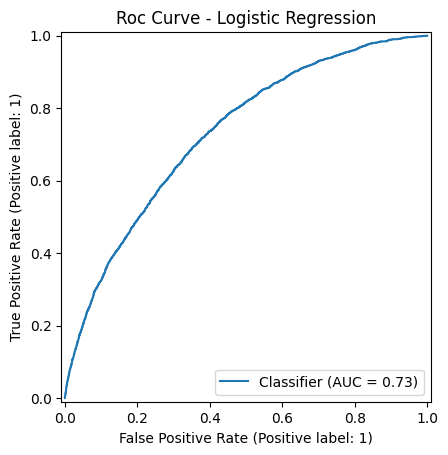

In [27]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Roc Curve - Logistic Regression")
plt.show()

## 3. Random Forest — Base Model

Next, I fit a Random Forest model as a nonlinear alternative. Because tree-based models do not require standardized numerical inputs, I use a preprocessing pipeline that imputes numerical values and encodes categorical variables before fitting the classifier.


In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
rf_preprocessor = ColumnTransformer([
    ("num",
     SimpleImputer(strategy = 'median'),
     numeric_features.columns),
    ('cat',
     categorical_pipeline,
     categorical_features.columns)
])

In [30]:
rf_model = Pipeline([
    ('preprocessor', rf_preprocessor),
    ('classifier', RandomForestClassifier(n_estimators = 100,
                                          random_state=19,
                                          n_jobs = -1))
])

In [31]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
       'fico_range_low', 'fico_range_high', 'revol_util'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index(['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       'verification_status', 'purpose'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=19))])

In [32]:
rf_results = evaluate_model("RF", rf_model, X_test, y_test)

rf_results

,Model,Precision Score,Recall Score,F1 Score
0,RF,0.49,0.13,0.21


### Base-Model Comparison

I collect each model's metrics into a master table so the candidates can be compared using the same evaluation framework rather than relying on a single metric.


In [33]:
# Comparing our base models so far we can see that they are preforming very similar

master_results = pd.concat([log_results, rf_results], ignore_index=True)

master_results

,Model,Precision Score,Recall Score,F1 Score
0,Log,0.55,0.12,0.20
1,RF,0.49,0.13,0.21


In [34]:
rf_y_pred = rf_model.predict(X_test)
rf_y_prob = rf_model.predict_proba(X_test)[:, 1]

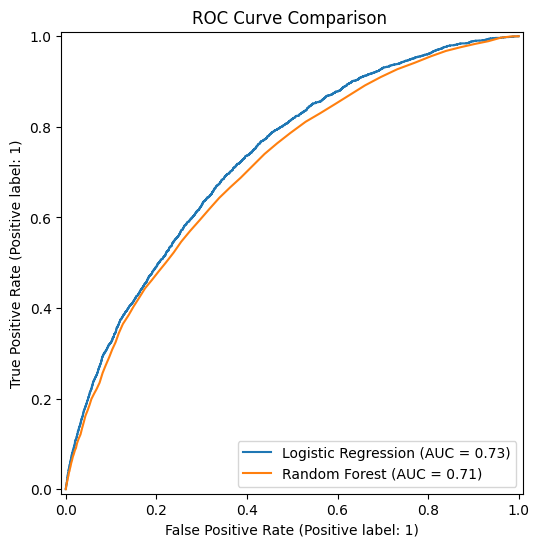

In [35]:
fig, ax = plt.subplots(figsize = (8, 6))

RocCurveDisplay.from_predictions(y_test,
                                 y_prob,
                                 name = "Logistic Regression",
                                 ax=ax)


RocCurveDisplay.from_predictions(y_test,
                                 rf_y_prob,
                                 name = "Random Forest",
                                 ax=ax)
plt.title("ROC Curve Comparison ")
plt.show()

## 4. XGBoost — Base Model

The third candidate is XGBoost, a gradient-boosted tree model. I evaluate it using the same test set and core classification metrics so its performance can be compared fairly with Logistic Regression and Random Forest.


In [36]:
from xgboost import XGBClassifier

In [37]:
xgb_model = Pipeline([
    ("preprocessor", rf_preprocessor),
    ("classifier", XGBClassifier(n_estimators=300,
                                 max_depth = 4,
                                 learning_rate = 0.05,
                                 random_state=19,
                                 eval_metric="logloss"))
])

xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
       'fico_range_low', 'fico_range_high', 'revol_util'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 hand...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [38]:
# Comparing all 3 base models we can see that Random Forest performs slightly better on 2 of the 3 metrics we are seeing

xgb_results = evaluate_model("XGB", xgb_model, X_test, y_test)

master_results = pd.concat([master_results, xgb_results], ignore_index=True)

master_results

,Model,Precision Score,Recall Score,F1 Score
0,Log,0.55,0.12,0.20
1,RF,0.49,0.13,0.21
2,XGB,0.55,0.13,0.21


In [39]:
xgb_y_pred = xgb_model.predict(X_test)
xgb_y_prob = xgb_model.predict_proba(X_test)[:, 1]

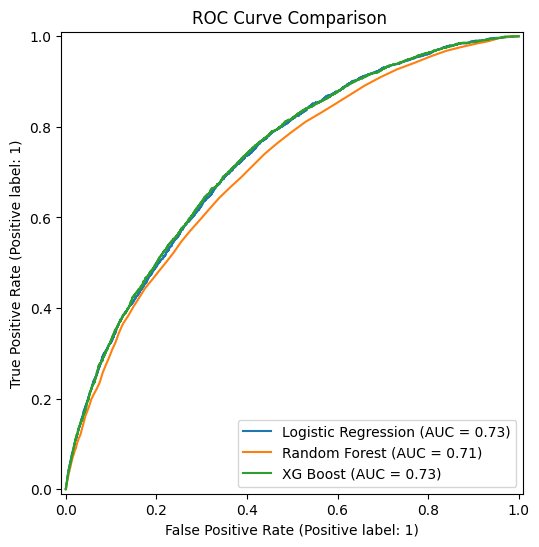

In [40]:
fig, ax = plt.subplots(figsize = (8, 6))

RocCurveDisplay.from_predictions(y_test,
                                 y_prob,
                                 name = "Logistic Regression",
                                 ax=ax)


RocCurveDisplay.from_predictions(y_test,
                                 rf_y_prob,
                                 name = "Random Forest",
                                 ax=ax)

RocCurveDisplay.from_predictions(y_test,
                                 xgb_y_prob,
                                 name = "XG Boost",
                                 ax=ax)
plt.title("ROC Curve Comparison ")
plt.show()

## 5. Threshold and Hyperparameter Tuning

The default classification threshold of 0.50 is not necessarily ideal for credit risk. I examine lower thresholds to understand the trade-off between precision and recall, while hyperparameter tuning is used to improve each model's ability to rank default risk.


### 5.1 XGBoost Tuning

I first use cross-validation to check whether XGBoost's ROC-AUC is reasonably stable across different training folds. I then use grid search to test combinations of key XGBoost hyperparameters and select the combination with the best cross-validated ROC-AUC.


In [41]:
from sklearn.model_selection import GridSearchCV

In [42]:
param_grid = {
    "classifier__max_depth": [3,4,5],
    "classifier__learning_rate": [0.03, 0.05, 0.01],
    "classifier__n_estimators": [200, 300, 400]
}

In [43]:
grid_search = GridSearchCV(estimator = xgb_model,
                           param_grid = param_grid,
                           scoring = "roc_auc",
                           cv=5,
                           n_jobs = -1,
                           verbose = 1)

In [44]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         SimpleImputer(strategy='median'),
                                                                         Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
       'fico_range_low', 'fico_range_high', 'revol_util'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          One...
                                                      max_delta_step=None,
                                                      max_depth=4,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=300,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.03, 0.05, 0.01],
                         'classifier__max_depth': [3, 4, 5],
                         'classifier__n_estimators': [200, 300, 400]},
             scoring='roc_auc', verbose=1)

In [45]:
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest CV ROC AUC:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 300}

Best CV ROC AUC:
0.7359912848447843


In [46]:
best_xgb_model = grid_search.best_estimator_

### 5.2 XGB Threshold Evaluation

Lowering the classification threshold labels more loans as potential defaults. This usually increases recall but reduces precision and accuracy. The threshold therefore represents a business trade-off rather than a parameter that should be selected from accuracy alone.


In [47]:
thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

threshold_results = []

for t in thresholds:

  y_pred_threshold = (xgb_y_prob >= t).astype(int)

  results = {
      "Threshold": t,
      "Precision Score": precision_score(y_test, y_pred_threshold),
      "Recall Score": recall_score(y_test, y_pred_threshold),
      "F1 Score": f1_score(y_test, y_pred_threshold)
  }

  threshold_results.append(results)

threshold_xgb_df = pd.DataFrame(threshold_results)

threshold_xgb_df

,Threshold,Precision Score,Recall Score,F1 Score
0,0.5,0.549550,0.129355,0.209416
1,0.4,0.486548,0.257498,0.336767
2,0.3,0.417853,0.426840,0.422299
3,0.2,0.339889,0.664950,0.449841
4,0.1,0.253617,0.918812,0.397510


In [48]:
tuned_xgb_results = evaluate_model("Tuned XGB", best_xgb_model, X_test, y_test, thresh = 0.1)

tuned_xgb_results

,Model,Precision Score,Recall Score,F1 Score
0,Tuned XGB,0.25,0.92,0.4


### 5.3 Logistic Regression Tuning

For Logistic Regression, I tune the regularization strength (`C`) while keeping L2 regularization. The goal is to determine whether a different amount of regularization improves ROC-AUC.


In [49]:
log_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"]
}

In [50]:
log_grid = GridSearchCV(estimator = model,
                        param_grid = log_param_grid,
                        scoring="roc_auc",
                        cv=5,
                        n_jobs=-1,
                        verbose=1)


In [51]:
log_grid.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
       'fico_range_low', 'fico_range_high', 'revol_util'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('impute...
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         Index(['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership',
       'verification_status', 'purpose'],
      dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=19))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__penalty': ['l2']},
             scoring='roc_auc', verbose=1)

In [52]:
print("Best Parameters:")
print(log_grid.best_params_)

print()

print("Best CV ROC AUC:")
print(round(log_grid.best_score_, 4))

Best Parameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l2'}

Best CV ROC AUC:
0.7339


In [53]:
best_log_model = log_grid.best_estimator_

### 5.4 Logistic Regression Threshold Evaluation

For Logistic, I evaluate how changing the probability threshold affects precision, recall, and F1. This is especially useful because missing a potential default can be more costly than incorrectly flagging a performing loan.


In [54]:
thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

threshold_results = []

for t in thresholds:

  y_pred_threshold = (y_prob >= t).astype(int)

  results = {
      "Threshold": t,
      "Precision Score": precision_score(y_test, y_pred_threshold),
      "Recall Score": recall_score(y_test, y_pred_threshold),
      "F1 Score": f1_score(y_test, y_pred_threshold)
  }

  threshold_results.append(results)

threshold_log_df = pd.DataFrame(threshold_results)

threshold_log_df

,Threshold,Precision Score,Recall Score,F1 Score
0,0.5,0.549374,0.119661,0.196517
1,0.4,0.482441,0.253862,0.332672
2,0.3,0.410767,0.418358,0.414528
3,0.2,0.334844,0.671615,0.446886
4,0.1,0.253119,0.921842,0.397181


In [55]:
tuned_log_results = evaluate_model("Tuned Log", best_log_model, X_test, y_test, thresh = 0.1)

tuned_results = pd.concat([tuned_xgb_results,tuned_log_results], ignore_index=True)

tuned_results

,Model,Precision Score,Recall Score,F1 Score
0,Tuned XGB,0.25,0.92,0.4
1,Tuned Log,0.25,0.92,0.4


### 5.5 Random Forest Threshold Evaluation

In [56]:
thresholds = [0.50, 0.40, 0.30, 0.20, 0.10]

threshold_results = []

for t in thresholds:

  y_pred_threshold = (rf_y_prob >= t).astype(int)

  results = {
      "Threshold": t,
      "Precision Score": precision_score(y_test, y_pred_threshold),
      "Recall Score": recall_score(y_test, y_pred_threshold),
      "F1 Score": f1_score(y_test, y_pred_threshold)
  }

  threshold_results.append(results)

threshold_rf_df = pd.DataFrame(threshold_results)

threshold_rf_df

,Threshold,Precision Score,Recall Score,F1 Score
0,0.5,0.485808,0.134808,0.211051
1,0.4,0.439357,0.273251,0.336944
2,0.3,0.379920,0.461981,0.416951
3,0.2,0.309982,0.687670,0.427334
4,0.1,0.248141,0.910027,0.389953


In [57]:
tuned_rf_results = evaluate_model("Tuned RF", rf_model, X_test, y_test, thresh = 0.1)

## 6. Tuned Model Comparison

The tuned models are compared using precision, recall, F1, accuracy, and ROC-AUC. Because the project focuses on credit risk rather than accuracy alone, I consider both ranking performance and the model's ability to identify defaults when selecting the champion model.


In [58]:
tuned_results = pd.concat([tuned_xgb_results,tuned_log_results, tuned_rf_results], ignore_index=True)


accuracy_auc_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [accuracy_score(y_test, y_pred),
                accuracy_score(y_test, rf_y_pred),
                accuracy_score(y_test, xgb_y_pred)],
    "ROC AUC": [roc_auc_score(y_test, y_prob),
                roc_auc_score(y_test, rf_y_prob),
                roc_auc_score(y_test, xgb_y_prob)]
})

print(f'Tuned Results: \n{tuned_results}')

print('-----------------------------------------------------------------------')

print(f'Accuracy and AUC: \n{accuracy_auc_results}')

Tuned Results: 
       Model  Precision Score  Recall Score  F1 Score
0  Tuned XGB             0.25          0.92      0.40
1  Tuned Log             0.25          0.92      0.40
2   Tuned RF             0.25          0.91      0.39
-----------------------------------------------------------------------
Accuracy and AUC: 
                 Model  Accuracy   ROC AUC
0  Logistic Regression  0.802893  0.730858
1        Random Forest  0.796973  0.711054
2              XGBoost  0.803259  0.732541


## 7. Probability of Default and Expected Loss

I use the selected XGBoost model to estimate a **Probability of Default (PD)** for each loan in the test portfolio.

Expected loss is then estimated using:

**Expected Loss = PD × LGD × EAD**

where **LGD** is Loss Given Default and **EAD** is Exposure at Default. For this project, I assume a constant LGD of 60% and use the original loan amount as EAD. These are simplifying portfolio assumptions rather than observed realized losses.


### Portfolio-Level Credit Risk

The model's predicted probabilities become loan-level PD estimates. Combining PD with the LGD and EAD assumptions converts model output into a dollar-based expected-loss estimate that is easier to interpret from a portfolio-risk perspective.


In [59]:
xgb_pd = best_xgb_model.predict_proba(X_test)[:, 1]

el_df = X_test.copy()

el_df["PD"] = xgb_pd
el_df["LGD"] = 0.60
el_df["EAD"] = X_test["loan_amnt"]

In [60]:
el_df[['PD', 'LGD', 'EAD']].head()

,PD,LGD,EAD
28430,0.468953,0.6,35000.0
57228,0.198940,0.6,22300.0
5405,0.077979,0.6,4800.0
64857,0.102751,0.6,14400.0
72093,0.094117,0.6,6000.0


In [61]:
el_df["Expected_Loss"] = (
    el_df["PD"]
    * el_df["LGD"]
    * el_df["EAD"]
)

In [62]:
el_df[
    ["loan_amnt", "PD", "LGD", "EAD", "Expected_Loss"]
].head()

,loan_amnt,PD,LGD,EAD,Expected_Loss
28430,35000.0,0.468953,0.6,35000.0,9848.022044
57228,22300.0,0.198940,0.6,22300.0,2661.812334
5405,4800.0,0.077979,0.6,4800.0,224.580395
64857,14400.0,0.102751,0.6,14400.0,887.767818
72093,6000.0,0.094117,0.6,6000.0,338.821578


In [66]:
portfolio_ead = el_df["EAD"].sum()
portfolio_el = el_df["Expected_Loss"].sum()

expected_loss_rate = portfolio_el / portfolio_ead

print(f"Total Exposure: ${portfolio_ead:,.2f}")
print(f"Expected Portfolio Loss: ${portfolio_el:,.2f}")
print(f"Expected Loss Rate: {expected_loss_rate:.2%}")

Total Exposure: $234,851,350.00
Expected Portfolio Loss: $30,648,321.71
Expected Loss Rate: 13.05%


## 8. Stress Testing

I stress the portfolio by increasing each borrower's modeled PD while holding LGD and EAD constant. This shows how expected portfolio loss changes if borrower credit conditions deteriorate.

The first scenario increases PD by 25%, with probabilities capped at 100%.


In [67]:
el_df["Stressed_PD"] = (el_df["PD"] * 1.25).clip(upper=1)

In [68]:
el_df["Stressed_Expected_Loss"] = (
    el_df["Stressed_PD"]
    * el_df["LGD"]
    * el_df["EAD"]
)

In [69]:
stressed_portfolio_el = el_df["Stressed_Expected_Loss"].sum()
increase_in_loss = (stressed_portfolio_el - portfolio_el)
percent_increase = increase_in_loss / portfolio_el

print(f"Baseline Expected Loss: ${portfolio_el:,.2f}")
print(f"Stressed Expected Loss: ${stressed_portfolio_el:,.2f}")
print(f"Increase in Expected Loss: ${increase_in_loss:,.2f}")
print(f"Percent Increase: {percent_increase:.2%}")

Baseline Expected Loss: $30,648,321.71
Stressed Expected Loss: $38,310,402.15
Increase in Expected Loss: $7,662,080.43
Percent Increase: 25.00%


### 8.1 Multiple Stress Scenarios

To make the stress test easier to compare, I evaluate baseline, mild, moderate, and severe scenarios using PD multipliers of 1.00, 1.10, 1.25, and 1.50.


### Scenario Design

Each stress scenario multiplies the baseline PD by a fixed factor and caps the result at 1.0. The scenarios are illustrative sensitivity tests rather than forecasts of a specific macroeconomic downturn.


In [70]:
scenarios = {
    "Baseline": 1.00,
    "Mild Stress": 1.10,
    "Moderate Stress": 1.25,
    "Severe Stress": 1.50
}

In [71]:
stress_results = []

for scenario, multiplier in scenarios.items():

    stressed_pd = (el_df["PD"] * multiplier).clip(upper=1)

    stressed_el = (
        stressed_pd
        * el_df["LGD"]
        * el_df["EAD"]
    ).sum()

    increase = stressed_el - portfolio_el

    stress_results.append({
        "Scenario": scenario,
        "PD Multiplier": multiplier,
        "Expected Loss": stressed_el,
        "Increase in Loss": increase,
        "Loss Rate": stressed_el / portfolio_ead}
    )

In [72]:
stress_df = pd.DataFrame(stress_results)

stress_df.style.format({
    "PD Multiplier": "{:.2f}",
    "Expected Loss": "${:,.2f}",
    "Increase in Loss": "${:,.2f}",
    "Loss Rate": "{:.2%}"
})

,Scenario,PD Multiplier,Expected Loss,Increase in Loss,Loss Rate
0,Baseline,1.00,"$30,648,321.71",$0.00,13.05%
1,Mild Stress,1.10,"$33,713,154.64","$3,064,832.93",14.36%
2,Moderate Stress,1.25,"$38,310,402.15","$7,662,080.43",16.31%
3,Severe Stress,1.50,"$45,929,337.75","$15,281,016.04",19.56%


### 8.2 Segmenting by Risk

In [ ]:
def assign_risk_band(pd_value):

    if pd_value < 0.10:
        return "Low Risk"

    elif pd_value < 0.20:
        return "Moderate Risk"

    elif pd_value < 0.40:
        return "High Risk"

    else:
        return "Very High Risk"

In [ ]:
el_df["Risk_Band"] = el_df["PD"].apply(assign_risk_band)

In [ ]:
el_df[
    ["PD", "Risk_Band"]
].head(10)

In [ ]:
risk_summary = (
    el_df
    .groupby("Risk_Band")
    .agg(
        Loans=("PD", "count"),
        Average_PD=("PD", "mean"),
        Total_Exposure=("EAD", "sum"),
        Expected_Loss=("Expected_Loss", "sum")
    )
    .reset_index()
)

In [ ]:
risk_summary["Loss_Rate"] = (
    risk_summary["Expected_Loss"]
    / risk_summary["Total_Exposure"]
)

In [ ]:
risk_summary.style.format({
    "Average_PD": "{:.2%}",
    "Total_Exposure": "${:,.2f}",
    "Expected_Loss": "${:,.2f}",
    "Loss_Rate": "{:.2%}"
})

## 9. Model Explainability

After evaluating portfolio risk, I examine what is driving XGBoost's predictions. I first review the model's built-in feature importance and then use SHAP to understand both overall feature effects and the direction in which features influence predicted default risk.

Because XGBoost is stored inside a scikit-learn pipeline, the already-fitted classifier and preprocessor are accessed separately for the SHAP analysis. This does **not** retrain or replace the model; it exposes the components that the pipeline normally handles automatically.


### Built-In XGBoost Feature Importance

XGBoost's built-in feature importance provides a first look at which transformed variables the model uses most heavily. Importance indicates predictive contribution, but it does not by itself tell us whether a feature increases or decreases predicted risk.


In [73]:
xgb_classifier = best_xgb_model.named_steps["classifier"]

In [74]:
import re

preprocessor = best_xgb_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

# Clean feature names to remove problematic characters for XGBoost/SHAP
# Replace any non-alphanumeric character (except underscore) with an underscore
cleaned_feature_names = [re.sub(r'[^a-zA-Z0-9_]+', '_', name) for name in feature_names]

# If there are consecutive underscores, replace them with a single underscore
cleaned_feature_names = [re.sub(r'__+', '_', name) for name in cleaned_feature_names]

# Ensure names don't start or end with an underscore if not intended
cleaned_feature_names = [name.strip('_') for name in cleaned_feature_names]

feature_names = cleaned_feature_names

In [75]:
importance = xgb_classifier.feature_importances_

In [76]:
feature_importance_df = pd.DataFrame({"Feature": feature_names,
                                      "Importance": importance})

feature_importance_df = feature_importance_df.sort_values(by = "Importance",
                                  ascending = False)

feature_importance_df.head(15)

,Feature,Importance
1,num_int_rate,0.251896
8,cat_term_60_months,0.176987
9,cat_grade_B,0.152963
59,cat_home_ownership_MORTGAGE,0.041689
61,cat_home_ownership_RENT,0.040759
4,num_dti,0.018922
5,num_fico_range_low,0.016422
63,cat_verification_status_Verified,0.014443
0,num_loan_amnt,0.012894
2,num_installment,0.012045


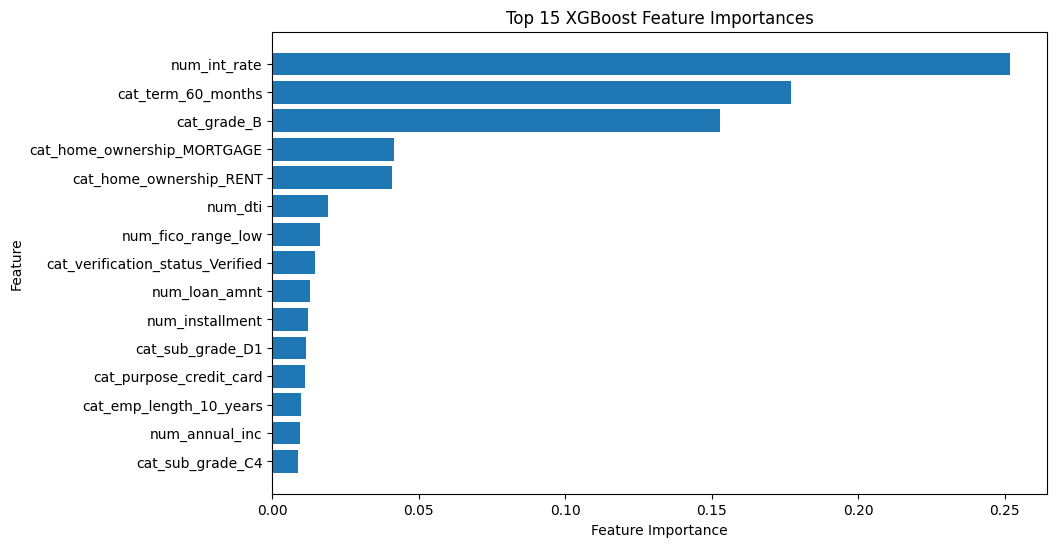

In [77]:
top_features = feature_importance_df.head(15).copy()

top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

top_features = top_features.sort_values(
    "Importance",
    ascending=True
)


plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.show()

### SHAP Analysis

SHAP provides a more detailed explanation of model predictions. The pipeline normally transforms the original features automatically before sending them to XGBoost. For `TreeExplainer`, I access the fitted preprocessor and classifier separately, transform the test data into the same representation used during training, and explain a 2,000-loan sample.

The sparse-to-dense conversion below changes how the sample is stored, not its underlying values. Sampling keeps the explanation computationally manageable.


In [78]:
import shap

In [79]:
X_test_transformed = preprocessor.transform(X_test)

X_test_transformed = pd.DataFrame.sparse.from_spmatrix(
    X_test_transformed,
    columns=feature_names,
    index=X_test.index
)

X_test_transformed.head()

,num_loan_amnt,num_int_rate,num_installment,num_annual_inc,num_dti,num_fico_range_low,num_fico_range_high,num_revol_util,cat_term_60_months,cat_grade_B,...,cat_purpose_debt_consolidation,cat_purpose_home_improvement,cat_purpose_house,cat_purpose_major_purchase,cat_purpose_medical,cat_purpose_moving,cat_purpose_other,cat_purpose_renewable_energy,cat_purpose_small_business,cat_purpose_vacation
28430,35000.0,16.99,869.66,136000.0,28.33,660.0,664.0,65.0,1.0,0,...,0,0,0,0,0,0,0,0,0,0
57228,22300.0,13.18,753.31,62000.0,14.36,750.0,754.0,1.7,0,0,...,0,0,0,0,0,0,1.0,0,0,0
5405,4800.0,9.17,153.02,53000.0,26.29,765.0,769.0,19.1,0,1.0,...,0,1.0,0,0,0,0,0,0,0,0
64857,14400.0,7.26,446.35,36000.0,27.32,720.0,724.0,33.2,0,0,...,1.0,0,0,0,0,0,0,0,0,0
72093,6000.0,7.89,187.72,70000.0,22.51,710.0,714.0,32.0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [80]:
X_shap = X_test_transformed.sample(
    n=2000,
    random_state=19
)

In [81]:
X_shap_dense = X_shap.sparse.to_dense()

In [82]:
explainer = shap.TreeExplainer(xgb_classifier)

In [83]:
shap_values = explainer(X_shap_dense)

### Portfolio-Level SHAP Interpretation

In the beeswarm plot, points to the **right** increase the model output toward default and points to the **left** decrease it. Color represents the feature value, with red indicating higher values and blue indicating lower values.

The plot shows that interest rate is the strongest driver in this sample. Higher interest rates and higher DTI generally push predictions toward default, while stronger FICO scores generally push predictions away from default. A 60-month term also appears as an important risk driver. These are model associations and should not be interpreted as causal effects.


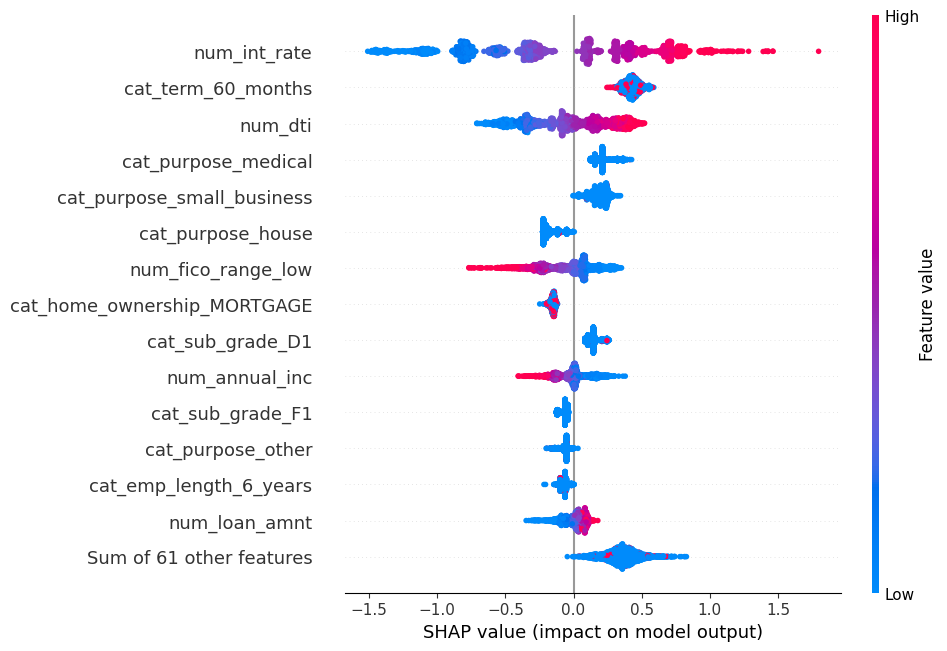

In [84]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

## 10. Highest-Risk Borrower Case Study

Finally, I identify the borrower with the highest predicted PD within the SHAP sample and trace that observation back to the original test data. A SHAP waterfall plot is then used to show which characteristics push this borrower's prediction toward or away from default.


### Finding the Highest Predicted PD

I calculate PDs for the 2,000-loan SHAP sample, locate the maximum probability, and use the preserved DataFrame index to retrieve the same borrower from the original untransformed test data.


In [85]:
shap_pd = xgb_classifier.predict_proba(X_shap_dense)[:, 1]

highest_risk_position = shap_pd.argmax()

shap_pd.argmax()

np.int64(1452)

In [86]:
highest_pd = shap_pd[highest_risk_position]

print(f"Highest Predicted PD: {highest_pd:.2%}")

Highest Predicted PD: 88.59%


In [87]:
borrower_index = X_shap_dense.index[highest_risk_position]

print("Original Row Index:", borrower_index)

Original Row Index: 45497


In [88]:
highest_risk_borrower = X_test.loc[borrower_index]

highest_risk_borrower

,45497
loan_amnt,14400.0
term,60 months
int_rate,27.31
installment,442.39
grade,G
sub_grade,G2
emp_length,1 year
home_ownership,RENT
annual_inc,40000.0
verification_status,Verified


### Individual SHAP Explanation

The waterfall plot starts from the model's baseline output and shows how this borrower's features move the prediction higher or lower. For the highest-risk borrower in the sample, the largest upward contributions come from the **23.99% interest rate**, **60-month term**, **33.91 DTI**, and **665 lower FICO bound**.

The waterfall's `f(x)` is the XGBoost model output used by SHAP, not a percentage probability. The borrower's actual PD is obtained separately from `predict_proba` above.


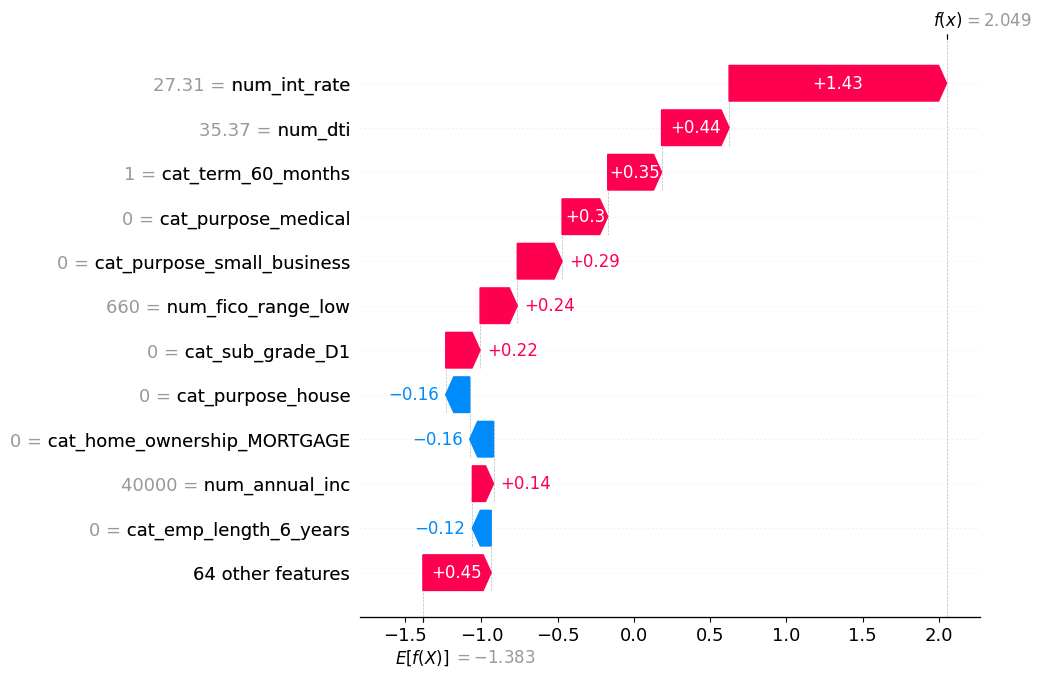

In [89]:
shap.plots.waterfall(
    shap_values[highest_risk_position],
    max_display=12
)

## 11. Key Takeaways

This notebook combines predictive modeling with portfolio credit-risk analysis. Logistic Regression, Random Forest, and XGBoost are evaluated under a consistent preprocessing framework, with tuning and threshold analysis used to examine model trade-offs. The selected XGBoost model is then translated into loan-level PD estimates, portfolio expected loss, stress-test scenarios, and interpretable feature-level explanations.
